 # Phần 1: Khảo Sát Dữ Liệu (Exploratory Data Analysis — EDA)

## 1. Kiểm tra chất lượng dữ liệu cơ bản

### 1.1. Thống kê mô tả

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style cho đồ thị
sns.set_theme(style="whitegrid")

# Load dữ liệu
df = pd.read_csv('data/AmesHousing.csv')

# Loại bỏ khoảng trắng thừa trong tên cột
df.columns = df.columns.str.strip()

print(f"Kích thước bộ dữ liệu: {df.shape}")

# Thống kê mô tả (mean, median, std, min, max, quartiles)
display(df.describe())

# Xem qua các biến phân loại
display(df.describe(exclude='number'))

Error: No connection selected.

### 1.2. Kiểm tra dữ liệu trùng lắp

In [11]:
num_duplicates = df.duplicated().sum()
print(f"Số lượng dòng dữ liệu bị trùng lắp (Duplicates): {num_duplicates}")

Error: No connection selected.

#### Nhận xét: Kiểm tra dữ liệu trùng lắp
Qua hàm `duplicated()`, ta thấy bộ dữ liệu Ames Housing không có dòng dữ liệu nào bị trùng lắp hoàn toàn (0 duplicates). Điều này chứng tỏ khâu thu thập dữ liệu gốc đã được quản lý định danh (thông qua mã PID của từng căn nhà) rất tốt. Do đó, nhóm không cần thực hiện bước xóa dòng trùng (drop duplicates) trong quá trình tiền xử lý.

## 2. Trực quan hóa dữ liệu (Histogram & Boxplot)

### 2.1. Khảo sát Biến mục tiêu (SalePrice)

In [12]:
from scipy.stats import norm

# Thiết kế biểu đồ phân tích cho biến mục tiêu
plt.figure(figsize=(12, 6))

# Vẽ Histogram kết hợp đường KDE
sns.histplot(df['SalePrice'], kde=True, stat="density", color="salmon", bins=50)

# Chèn thêm đường cong phân phối chuẩn (Normal Distribution) để so sánh độ lệch
mu, std = norm.fit(df['SalePrice'].dropna())
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, linestyle='--', label=rf'Normal Dist. ($\mu$={mu:.0f}, $\sigma$={std:.0f})')

plt.title('Phân phối của biến mục tiêu: SalePrice', fontsize=16)
plt.xlabel('Giá bán (USD)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.legend()
plt.show()

# Vẽ Boxplot cho SalePrice để soi outliers của y
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['SalePrice'], color='salmon')
plt.title('Boxplot của SalePrice', fontsize=14)
plt.show()

Error: No connection selected.

#### Nhận xét về Biến mục tiêu (Target Variable Analysis)
* **Phân phối:** Biểu đồ Histogram cho thấy `SalePrice` bị lệch phải (Right-skewed) rõ rệt. Đỉnh của phân phối tập trung ở khoảng 130,000 - 160,000 USD, nhưng có một dải đuôi dài kéo về phía các mức giá cao (trên 500,000 USD).
* **So sánh với Phân phối chuẩn:** Đường cong thực tế (Salmon) lệch đáng kể so với đường lý thuyết (Black dashed), cho thấy dữ liệu không tuân theo phân phối chuẩn.
* **Outliers:** Boxplot xác nhận sự tồn tại của nhiều giá trị ngoại lệ ở phía cận trên (giá cao).
* **Kết luận cho OLS:** Để thỏa mãn giả định về phân phối chuẩn của phần dư trong mô hình OLS, việc áp dụng phép biến đổi **Log-transformation** cho `SalePrice` là bắt buộc trước khi đưa vào huấn luyện.

### 2.2. Khảo sát Biến dự báo (Predictors)

In [13]:
# Tìm các biến có tương quan cao nhất với SalePrice để ưu tiên khảo sát
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Lấy top 30 biến tương quan mạnh nhất với SalePrice
top_30_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(30).index

# Định nghĩa danh sách các biến mang tính chất thời gian (năm/tháng)
temporal_cols = ['Year Built', 'Year Remod/Add', 'Garage Yr Blt', 'Yr Sold', 'Mo Sold']

# Lọc ra top các biến tương quan cao, bỏ qua biến mục tiêu (index 0)
# và bỏ qua các biến nằm trong danh sách temporal_cols
predictors_to_plot = [col for col in top_30_features[1:] if col not in temporal_cols][:12]

print(f"12 biến được chọn để vẽ phân phối: {predictors_to_plot}")

# Vẽ lưới Histogram 3x4
plt.figure(figsize=(20, 15))
for i, col in enumerate(predictors_to_plot, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Phân phối của {col}', fontsize=14)
    plt.xlabel(col, fontsize=12, fontweight='bold')
    plt.ylabel('Tần suất', fontsize=12)
plt.tight_layout()
plt.show()

# Vẽ lưới Boxplot 3x4
plt.figure(figsize=(20, 15))
for i, col in enumerate(predictors_to_plot, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot của {col}', fontsize=14)
    plt.ylabel('Giá trị', fontsize=12)
    plt.xlabel(col, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Error: No connection selected.

#### Nhận xét về Phân phối của các Biến dự báo
Qua quan sát biểu đồ Histogram của 12 biến độc lập quan trọng nhất, ta rút ra các đặc điểm sau:

* **Các biến đo lường diện tích (`Gr Liv Area`, `Total Bsmt SF`, `1st Flr SF`):** Hầu hết đều có xu hướng lệch phải (Right-skewed). Điều này phản ánh thực tế cấu trúc nhà ở: đại đa số là nhà có diện tích trung bình, chỉ một thiểu số ít là các dinh thự hoặc nhà có diện tích cực lớn.
* **Các biến đánh giá chất lượng (`Overall Qual`, `Garage Cars`, `Full Bath`):** Có dạng phân phối đa đỉnh (Multimodal) hoặc phân bố theo cụm rời rạc. Đây là đặc trưng hiển nhiên của các biến mang tính chất thứ bậc (Ordinal) hoặc số đếm (Count).
* **Đề xuất xử lý:** Sự lệch phải của các biến diện tích có thể làm tăng phương sai của phần dư trong mô hình OLS. Nhóm sẽ cân nhắc áp dụng phép biến đổi Logarit (Log-transform) cho các biến số học liên tục bị lệch nặng để đưa chúng về dạng chuẩn hơn trong bước Pipeline.

#### Nhận xét về Giá trị ngoại lệ (Visual Outliers) của các Biến dự báo
Qua quan sát hình dáng biểu đồ Boxplot, ta nhận thấy sự xuất hiện của rất nhiều điểm ngoại lệ (các chấm đen nằm ngoài râu của đồ thị):

* **Các điểm đòn bẩy tiềm năng (Potential Leverage Points):** Dễ thấy nhất ở biến `Gr Liv Area` và `Total Bsmt SF`. Có những quan sát nằm tách biệt hoàn toàn ở phía trên đỉnh đồ thị (đại diện cho các căn nhà có diện tích cực lớn). Trong lý thuyết OLS, đây là những điểm có nguy cơ trở thành "đòn bẩy", kéo lệch đường hồi quy của toàn bộ tập dữ liệu.
* **Các biến tiện ích đặc thù:** Những biến như `Mas Vnr Area` (Diện tích ốp gạch/đá) hay `Wood Deck SF` (Diện tích sàn gỗ) có mật độ điểm ngoại lệ rất dày đặc. Lý do trực quan là phần lớn các căn nhà không có tiện ích này (giá trị = 0), khiến phần thân hộp (hộp chứa 50% dữ liệu) bị bóp nghẹt lại, đẩy các giá trị > 0 ra ngoài khoảng râu đồ thị.
* **Định hướng bước tiếp theo:** Từ những quan sát trực quan này, nhóm sẽ tiến hành định lượng cụ thể số lượng ngoại lệ bằng công thức thống kê ở phần "Phân tích chuyên sâu" bên dưới để có cơ sở đưa ra thuật toán xử lý (Winsorization) trong `DataPipeline`.

### 2.3. Đánh giá mức độ tương quan (Heatmap)

In [14]:
# Lấy top 15 biến có độ tương quan cao nhất với SalePrice
top_15_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(15).index
top_15_corr = df[top_15_features].corr()

# Vẽ Clustermap để thuật toán tự động gom các biến đa cộng tuyến lại gần nhau
cluster = sns.clustermap(top_15_corr,
                         annot=True,
                         fmt=".2f",
                         cmap='coolwarm',
                         linewidths=0.5,
                         figsize=(12, 10), # Clustermap dùng figsize bên trong hàm
                         annot_kws={"size": 10},
                         tree_kws={"linewidths": 1.5}) # Làm nét đường cây phân cụm

cluster.fig.suptitle('Ma trận tương quan phân cụm (Clustermap) của 15 biến quan trọng', fontsize=16, y=1.05)

plt.setp(cluster.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.setp(cluster.ax_heatmap.get_yticklabels(), rotation=0)

plt.show()

Error: No connection selected.

#### Nhận xét về Ma trận tương quan phân cụm (Clustermap)
Thay vì sắp xếp thủ công, nhóm sử dụng thuật toán Phân cụm phân cấp (Hierarchical Clustering) thông qua biểu đồ Clustermap để máy tính **tự động** tính toán khoảng cách và gom nhóm các biến có độ tương quan cao lại với nhau. Qua quan sát, ta rút ra các kết luận quan trọng:

* **Các biến dự báo "át chủ bài":** `Overall Qual` (Chất lượng tổng thể) và `Gr Liv Area` (Diện tích sinh hoạt) đã khẳng định vị thế là 2 biến độc lập có tác động mạnh mẽ nhất đến `SalePrice`. Đây sẽ là các biến mang trọng số cao trong phương trình hồi quy.
* **Phát hiện Đa cộng tuyến (Multicollinearity) tự động:** Nhờ cây phân cụm (dendrogram), thuật toán đã nhóm thành công 4 cụm biến (các ô màu đỏ sẫm tạo thành khối vuông) có hiện tượng đa cộng tuyến rất cao:
  1. **`Garage Cars` & `Garage Area`:** Sức chứa (số xe) và diện tích vật lý của gara tỉ lệ thuận trực tiếp với nhau.
  2. **`TotRms AbvGrd` & `Gr Liv Area`:** Tổng số phòng và tổng diện tích sinh hoạt trên mặt đất về cơ bản đang đo lường cùng một quy mô không gian.
  3. **`1st Flr SF` & `Total Bsmt SF`:** Khuôn viên diện tích mặt bằng tầng 1 thường được xây dựng khớp với diện tích tầng hầm bên dưới nó.
  4. **`Year Built` & `Garage Yr Blt`:** Đại đa số gara đều được xây dựng cùng năm với thời điểm cất nhà chính.
* **Đề xuất xử lý cho mô hình OLS:** Hiện tượng đa cộng tuyến sẽ làm ma trận thiết kế bị suy biến và gây nhiễu các hệ số $\beta$. Ở bước `DataPipeline`, nhóm đề xuất sẽ **chỉ giữ lại một biến** trong mỗi cặp để đưa vào huấn luyện. Điển hình như cặp số 4, nhóm sẽ loại bỏ `Garage Yr Blt` (vì cột này chứa 159 giá trị khuyết) và giữ lại `Year Built` nhằm tối ưu hóa bộ dữ liệu.

#### 2.4. Khảo sát tính tuyến tính giữa các Biến độc lập và Biến mục tiêu (SalePrice)

In [15]:
plt.figure(figsize=(18, 6))

# 1. Gr Liv Area vs SalePrice (Biến diện tích liên tục)
plt.subplot(1, 2, 1)
sns.regplot(data=df, x='Gr Liv Area', y='SalePrice',
            scatter_kws={'alpha':0.5, 's':20},
            line_kws={'color':'red'})
plt.title('Mối quan hệ giữa Diện tích sinh hoạt và Giá bán', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Overall Qual vs SalePrice (Biến chất lượng rời rạc)
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Overall Qual', y='SalePrice', hue='Overall Qual', palette='viridis', legend=False)
plt.title('Mối quan hệ giữa Chất lượng tổng thể và Giá bán', fontsize=14)

plt.tight_layout()
plt.show()

Error: No connection selected.

#### Nhận xét về tính tuyến tính và tương quan
Biểu đồ Scatter Plot và Boxplot kết hợp với đường hồi quy (Red line) cho thấy:

* **Tính tuyến tính:** Biến `Gr Liv Area` thể hiện một mối quan hệ tuyến tính thuận rất rõ rệt với `SalePrice`. Khi diện tích tăng, giá nhà có xu hướng tăng theo một tỉ lệ ổn định. Điều này cho thấy mô hình hồi quy tuyến tính là một lựa chọn hợp lý để thử nghiệm ở bước tiếp theo.
* **Hiện tượng "loe phễu":** Ở biểu đồ bên trái, ta thấy khi diện tích càng lớn, các điểm dữ liệu càng phân tán rộng hơn (hình cái loa). Đây là dấu hiệu của phương sai thay đổi (Heteroscedasticity), củng cố thêm lý do tại sao nhóm cần áp dụng Log-transform ở bước sau để "nén" phương sai này lại.
* **Biến chất lượng:** Với `Overall Qual`, giá nhà tăng theo bậc thang khi chất lượng tăng. Tuy nhiên, ở các mức chất lượng cao nhất (9 và 10), sự biến động về giá là cực lớn, cho thấy chất lượng chỉ là điều kiện cần, còn giá cuối cùng phụ thuộc thêm nhiều yếu tố khác.

## 3. Phân tích chuyên sâu

### 3.1. Phân tích Missing Values

In [16]:
import missingno as msno
import matplotlib.pyplot as plt

# Thống kê số lượng và tỷ lệ missing
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Số lượng': missing, 'Tỷ lệ %': missing_pct})
missing_report = missing_report[missing_report['Số lượng'] > 0].sort_values('Tỷ lệ %', ascending=False)
print(f"Có {len(missing_report)} biến bị missing:\n")
display(missing_report)

# Chỉ vẽ các cột có missing
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    msno.bar(df[missing_cols], figsize=(12, 5), fontsize=10)
    plt.title("Tỷ lệ missing values")
    plt.show()
else:
    print("Không có cột nào bị missing.")

Error: No connection selected.

### Phân tích tổng quan dữ liệu khuyết (Missing Values)

Thay vì liệt kê đơn lẻ, việc phân tích dữ liệu khuyết được nhóm chia thành các cụm đặc trưng có cùng bản chất nghiệp vụ để dễ dàng nhận diện pattern (quy luật bị khuyết). Trực quan hóa dữ liệu cho thấy các giá trị `NaN` không phân bố ngẫu nhiên mà tập trung vào 3 nhóm chính:

1. **Nhóm khuyết diện rộng (> 80%):** Bao gồm `Pool QC` (99.5%), `Misc Feature` (96.3%), `Alley` (93.2%), `Fence` (80.4%). Đây là các tiện ích "xa xỉ" hoặc không phổ biến. Tỉ lệ khuyết cao phản ánh thực tế phần lớn các ngôi nhà không sở hữu các tiện ích này.
2. **Nhóm khuyết theo cụm cấu trúc (Structural Clusters - ~2.5% đến 5%):**
   - **Cụm Garage:** Các biến `Garage Type`, `Garage Finish`, `Garage Qual`, `Garage Cond`, `Garage Yr Blt` luôn bị khuyết cùng lúc trên cùng các dòng dữ liệu.
   - **Cụm Basement (Tầng hầm):** Tương tự, `Bsmt Qual`, `Bsmt Cond`, `Bsmt Exposure`, `BsmtFin Type 1/2` có pattern khuyết đồng thời.
   $\rightarrow$ Trạng thái khuyết này có tính hệ thống cao, đại diện cho việc ngôi nhà hoàn toàn không có Gara hoặc Tầng hầm.
3. **Nhóm khuyết rời rạc (MAR / Lỗi nhập liệu):** - `Lot Frontage` (~16.7%): Mọi lô đất đều phải có mặt tiền tiếp giáp, việc khuyết dữ liệu có thể do khó khăn trong việc đo đạc ở một số khu vực nhất định.
   - `Mas Vnr Type / Area` và `Electrical`: Tỉ lệ khuyết rất nhỏ, mang dấu vết của sự bỏ sót ngẫu nhiên trong quá trình số hóa dữ liệu.

*Nhận định:* Phần lớn dữ liệu khuyết trong tập Ames Housing chứa đựng **thông tin nghiệp vụ quan trọng** (nhà không có tiện ích) thay vì lỗi thu thập. Do đó, tuyệt đối không được dùng phương pháp xóa dòng (Listwise Deletion) để tránh mất mát thông tin nghiêm trọng.

### 3.2. Phát hiện Outliers bằng phương pháp IQR

In [17]:
# 1. ĐỊNH LƯỢNG OUTLIERS BẰNG PHƯƠNG PHÁP IQR
outlier_counts = {}
iqr_zero_cols = []

def count_outliers_iqr_advanced(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    # Bắt lỗi: Nếu IQR = 0, phương pháp này trở nên vô nghĩa
    if IQR == 0:
        return -1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    return len(outliers)

# Quét qua toàn bộ các cột numeric
for col in numeric_cols:
    count = count_outliers_iqr_advanced(df, col)
    if count == -1:
        iqr_zero_cols.append(col)
    else:
        outlier_counts[col] = count

# Hiển thị bảng Outliers hợp lệ
outliers_df = pd.DataFrame(list(outlier_counts.items()), columns=['Biến (Feature)', 'Số lượng Outliers'])
outliers_df['Tỉ lệ (%)'] = (outliers_df['Số lượng Outliers'] / len(df)) * 100
outliers_df = outliers_df[outliers_df['Số lượng Outliers'] > 0].sort_values(by='Số lượng Outliers', ascending=False)

print("BẢNG THỐNG KÊ OUTLIERS HỢP LỆ (IQR > 0)")
display(outliers_df.head(10))

print("\nDANH SÁCH CÁC BIẾN KHÔNG THỂ ÁP DỤNG IQR (IQR = 0)")
print(f"Tổng cộng có {len(iqr_zero_cols)} biến. Danh sách chi tiết:")
print(iqr_zero_cols)

# 2. XÁC ĐỊNH ĐIỂM ĐÒN BẨY CỰC ĐOAN
leverage_candidates = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 300000)]
print(f"\nĐIỂM ĐÒN BẨY TIỀM NĂNG (Gr Liv Area > 4000 & SalePrice < 300k): {len(leverage_candidates)} quan sát")

Error: No connection selected.

#### Nhận xét về Giá trị ngoại lệ & Giới hạn của phương pháp IQR
Trong quá trình định lượng Outliers, nhóm phát hiện một vấn đề mang tính nền tảng của thuật toán IQR: Có nhiều biến sở hữu khoảng tứ phân vị bằng 0 ($IQR = 0$). Nhóm đã tiến hành lọc riêng các biến này ra khỏi bảng thống kê và phân loại thành 2 nhóm bản chất:

1. **Nhóm dữ liệu thưa thớt (Zero-inflated):** Tiêu biểu là `BsmtFin SF 2`, `Enclosed Porch`, `Screen Porch`. Hơn 80% giá trị của các biến này là 0 (nhà không có tiện ích này). Khi $Q1 = 0$ và $Q3 = 0$, mọi giá trị $> 0$ đều bị IQR kết luận là ngoại lệ. Điều này là **vô lý về mặt nghiệp vụ**, vì việc có một cái hiên nhà không thể bị coi là điểm dị thường.
2. **Nhóm dữ liệu thiếu phương sai (Near-constant):** Tiêu biểu là `Kitchen AbvGr`. 99% các căn nhà có đúng 1 nhà bếp ($Q1 = 1, Q3 = 1$). Những căn có 2 bếp sẽ bị IQR bắt lỗi. Thực chất đây là những căn hộ thiết kế đặc biệt (nhà ghép/duplex), việc áp dụng công thức khoảng cách cho biến gần như hằng số này là **không phù hợp**.

**Định hướng xử lý trong Pipeline:**
* **Đối với các biến có IQR bình thường (như `SalePrice`, `Gr Liv Area`):** Nhóm sẽ áp dụng kỹ thuật **Winsorization** (chặn phân vị 1% - 99%) để giảm sát thương của các điểm đòn bẩy.
* **Đối với nhóm $IQR = 0$:** Nhóm hoàn toàn **không áp dụng kỹ thuật gọt Outliers**. Thay vào đó, nếu cần thiết, nhóm sẽ xem xét chuyển đổi chúng thành biến phân loại nhị phân (ví dụ: `Has_Enclosed_Porch`: 1/0) để đưa vào mô hình hiệu quả hơn.

#### Nhận xét về Điểm đòn bẩy
Các điểm có Gr Liv Area > 4000 nhưng SalePrice < 300k là bất thường so với xu hướng chung — diện tích lớn nhưng giá lại thấp. Trong OLS, những điểm này có thể trở thành leverage points làm lệch đường hồi quy. Sẽ được loại khỏi tập train trong DataPipeline.

# Phần 2: Tiền xử lý missing values + Feature Engineering

## 2.1. Phân tích cơ chế Missing Values và Kỹ thuật Xử lý

Không phải mọi giá trị thiếu đều có cùng bản chất. Trước khi chọn kỹ thuật xử lý, cần xác định **cơ chế khuyết** (missing mechanism) của từng nhóm biến, vì chọn sai kỹ thuật sẽ tạo ra dữ liệu mâu thuẫn logic và làm sai lệch mô hình.

---

#### Nhóm 1 — Biến định danh và near-zero variance (DROP)

`Order` và `PID` là số thứ tự và mã định danh, unique mỗi hàng — không mang thông tin dự báo, cần drop trước mọi bước xử lý.

`Utilities` (99.9% = `AllPub`) và `Street` (99.6% = `Pave`) gần như hằng số — không phân biệt được các ngôi nhà với nhau, đưa vào mô hình chỉ tạo nhiễu.

**Kỹ thuật: Drop hoàn toàn.**

---

#### Nhóm 2 — Biến >80% missing: MNAR có cấu trúc (DROP + tạo cờ)

`Pool QC` (99.6%), `Misc Feature` (96.4%), `Alley` (93.2%), `Fence` (80.5%) — tỷ lệ missing quá cao không phải do lỗi ghi chép mà vì đại đa số nhà thực sự **không có** những tiện ích này. Đây là **MNAR (Missing Not At Random)** có cấu trúc.

Tuy nhiên thông tin "có hay không" vẫn có giá trị dự báo, nên trước khi drop cần tạo biến cờ: `Has_Pool`, `Has_Alley`, `Has_Fence`, `Has_Misc_Feature`.

**Kỹ thuật: Tạo cờ binary → Drop cột gốc.**

---

#### Nhóm 3 — Garage: MNAR có cấu trúc + MAR

Khi xác định nhà có garage hay không, **không thể chỉ dựa vào một cột**. Đối chiếu chéo 3 cột (`Garage Type`, `Garage Area`, `Garage Cars`) cho thấy 157 nhà không có garage, và tất cả biến garage của nhóm này đều null đồng bộ — đây là **MNAR**: nhà không có garage thì không có năm xây, diện tích, chất lượng garage.

Vấn đề điển hình: nếu áp dụng khuôn mẫu "biến số → điền median", `Garage Yr Blt` của 157 nhà không có garage sẽ được điền ~1979 — mâu thuẫn hoàn toàn với `Garage Type = 'None'`. Mô hình OLS sẽ nhận tín hiệu nhiễu: nhà không có garage nhưng lại có năm xây garage.

**Các trường hợp cần xử lý:**

| Trường hợp | Số lượng | Cơ chế | Kỹ thuật |
|------------|----------|--------|-----------|
| Không có garage | 157 hàng | MNAR | Gán `'None'` cho `Garage Type` và các biến categorical, `0` cho `Garage Cars` và `Garage Area`, giữ `NaN` cho `Garage Yr Blt` |
| Có garage, thiếu `Garage Yr Blt` | 2 hàng | MAR | Median theo nhóm (thập niên `Year Built` × `Garage Type`), fallback theo `Garage Type`, fallback toàn cục |
| Có garage, thiếu `Garage Area` | 1 hàng | MAR | Median theo `Garage Type` |
| Có garage, thiếu `Garage Cars` | 1 hàng | MAR | Median theo nhóm diện tích `Garage Area` (chỉ dùng dòng có `Garage Cars > 0` và `Garage Area > 0` để tính bins) |
| Có garage, thiếu `Garage Type` (do `Area/Cars > 0` nhưng `Type` bỏ trống) | edge case | MAR | Mode theo nhóm diện tích `Garage Area` (chỉ dùng dòng có `Garage Type` đã biết để tính bins, tránh index mismatch) |
| `Garage Type = 'Attchd'` có `Garage Yr Blt < Year Built` | 5 hàng | Lỗi nhập liệu | Sửa `Garage Yr Blt = Year Built` (garage đính kèm không thể xây trước nhà) |
| `Garage Finish`, `Garage Qual`, `Garage Cond` | 159 hàng mỗi biến | MAR | Mode theo nhóm (`Garage Type` × `Overall Qual`), fallback theo `Garage Type` |

**Kỹ thuật xử lý `Garage Yr Blt`:**
- Nhà không có garage: giữ `NaN` (không gán giá trị vì feature không tồn tại).
- Nhà có garage nhưng missing (2 hàng MAR): median theo nhóm thập niên × loại garage.
- Sau xử lý, `Garage Yr Blt` chỉ còn `NaN` ở nhóm không có garage — sẽ được xử lý tiếp trong Feature Engineering (tạo `Has_Garage` và `Garage_Age`).
- Kiểm tra thêm ở Bước 5: nếu `Garage Yr Blt > Yr Sold` (lỗi nhập liệu rõ ràng) thì gán lại bằng `Year Built`.

---

#### Nhóm 4 — Basement: MNAR + MAR

80 nhà không có tầng hầm (anchor: `Total Bsmt SF = 0` hoặc tổng diện tích các phần = 0). Toàn bộ biến basement của nhóm này đều là **MNAR**.

Tuy nhiên có một số hàng null trong khi nhà **có** tầng hầm — đây là **MAR** (lỗi bỏ sót khi ghi chép), cần xử lý riêng.

**Lưu ý thứ tự xử lý:** `Total Bsmt SF` và `Bsmt Unf SF` có quan hệ kế toán (`Total = Fin1 + Fin2 + Unf`). Phải xử lý theo đúng thứ tự nhân quả:
1. Tính `Total Bsmt SF` trước (từ tổng các phần, dùng `fillna(0)` để tránh NaN propagation)
2. Tính `Bsmt Unf SF` sau (phần dư = `Total - Fin1 - Fin2`)

Đảo thứ tự sẽ gây NaN propagation: `NaN - 500 - 0 = NaN`.

| Biến                                         | Số lượng MAR | Kỹ thuật |
|----------------------------------------------|--------------|--------|
| `Bsmt Exposure`                              | 3 hàng       | Mode theo `BsmtFin Type 1` của nhà có tầng hầm (`notna()` filter); fallback global mode nếu Type không có trong lookup |
| `BsmtFin Type 2`                             | 1 hàng       | Mode của nhà có `BsmtFin SF 2 > 0` |
| `BsmtFin SF 1`                               | 1 hàng       | Median theo `BsmtFin Type 1` (chỉ dùng dòng có `SF > 0`) |
| `BsmtFin SF 2`                               | 1 hàng       | Median theo `BsmtFin Type 2` (chỉ dùng dòng có `SF > 0`) |
| `BsmtFin Type 1/2` (SF = 0, Type null)       | một số hàng | Gán thẳng `'Unf'` — diện tích = 0 thì loại hoàn thiện chắc chắn là chưa hoàn thiện (logic, không phải imputation) |
| `BsmtFin Type 1/2` (biết SF > 0, thiếu Type) | một số hàng  | Mode theo nhóm diện tích SF (bins tính từ dòng có `SF > 0` và có tầng hầm, tránh giá trị 0 kéo lệch ranh giới nhóm) |
| `Bsmt Unf SF`                                | 1 hàng       | Tính từ phần dư: `Total Bsmt SF - Fin1 - Fin2` (quan hệ kế toán) |
| `Total Bsmt SF`                              | 1 hàng       | Tính từ tổng: `Fin1 + Fin2 + Unf` |
| `Bsmt Full Bath`                             | 2 hàng       | Điền `0` (tầng hầm không bắt buộc có phòng tắm) |
| `Bsmt Half Bath`                             | 2 hàng       | Điền `0` |
| `Bsmt Qual`                                  | 80 hàng      | Mode theo nhóm quantile `Total Bsmt SF` (tương quan r=0.46); bins tính từ dòng có tầng hầm và `SF > 0` |
| `Bsmt Cond`                                  | 80 hàng      | Mode theo thập niên `Year Built` — nhà trước 1900 có tỷ lệ `'Fa'` lên đến 28–33%, khác biệt đáng kể so với global mode 89% là `'TA'`; fallback `'TA'` |

---

#### Nhóm 5 — Fireplace Qu: MNAR thuần túy

1,422 hàng (48.5%) `Fireplace Qu = NaN` khi `Fireplaces = 0` — 100% khớp, không có ngoại lệ. Không có lò sưởi thì không có chất lượng lò sưởi. Đây là **MNAR** rõ ràng nhất trong dataset.

Kiểm tra data thực tế xác nhận: không có hàng nào `Fireplaces > 0` mà `Fireplace Qu = NaN`, do đó **không cần imputation cho nhóm MAR**.

**Kỹ thuật: `Fireplaces = 0` → điền `'None'`.** Pipeline được thiết kế phòng thủ (defensive): nếu trong tương lai xuất hiện trường hợp MAR (nhà có lò sưởi nhưng thiếu `Fireplace Qu`), tự động điền mode theo nhóm `(Overall Qual, Bldg Type)` — phản ánh thực tế là chất lượng lò sưởi phụ thuộc vào chất lượng tổng thể và loại nhà.

---

#### Nhóm 6 — Mas Vnr (Lớp ốp đá/gạch): MNAR + MAR nhỏ

1,775 hàng (60.6%) `Mas Vnr Type = NaN` — phần lớn là nhà không có lớp ốp đá (**MNAR**). Anchor được xác định bằng đối chiếu chéo: `Mas Vnr Area > 0` HOẶC `Mas Vnr Type ≠ NaN và ≠ 'None'`.

7 hàng có diện tích ốp đá > 0 nhưng thiếu loại (`Mas Vnr Type = NaN`) — **MAR** (lỗi nhập liệu). Không thể điền mode toàn tập vì phân phối loại ốp đá phụ thuộc diện tích: diện tích nhỏ thường là `BrkFace`, lớn thường là `Stone`. Bins cố định `[0, 100, 300, 10000]` được chọn dựa trên đặc tính vật lý của từng loại vật liệu.

**Kỹ thuật:**
- MNAR (1,768 hàng): điền `'None'` / `0`
- MAR — 7 hàng thiếu `Mas Vnr Type`: mode theo nhóm diện tích (small/medium/large)
- Thiếu `Mas Vnr Area` khi có ốp đá: không xuất hiện trong dataset này (0 hàng); pipeline xử lý phòng thủ bằng median theo loại `Mas Vnr Type` nếu gặp ở dữ liệu khác

---

#### Nhóm 7 — Lot Frontage: MAR

490 hàng (16.7%) missing. Mọi lô đất đều có mặt tiền — việc thiếu là do **bỏ sót khi đo đạc** → **MAR**. Bằng chứng: tỷ lệ missing thay đổi rõ rệt theo khu vực (`GrnHill`: 100%, `Landmrk`: 100%, `ClearCr`: 54.5%, trong khi nhiều khu vực khác <10%).

Quan trọng hơn, median `Lot Frontage` dao động rất lớn theo neighborhood: từ 21 ft (`BrDale`) đến 92 ft (`NridgHt`), trong khi global median chỉ là 68 ft. Dùng global median sẽ sai lệch lớn cho các khu vực đặc thù.

**Kỹ thuật:** Grouped median theo `Neighborhood`. Fallback bằng global median cho những dòng vẫn missing sau grouped median — thực tế có **3 dòng** phải dùng global median fallback (thuộc các neighborhood quá ít mẫu để tính median).

---

#### Nhóm 8 — Electrical: MCAR

Chỉ 1 hàng missing (0.03%), không có quy luật kết hợp với bất kỳ biến nào — **MCAR** thuần túy. `SBrkr` chiếm 91.5% giá trị.

**Kỹ thuật: Điền mode = `'SBrkr'`.**

---

#### Tóm tắt cơ chế và kỹ thuật

| Nhóm | Biến | Missing | Cơ chế | Kỹ thuật |
|------|------|---------|---------|-----------|
| Định danh / NZV | `Order`, `PID`, `Utilities`, `Street` | — | — | Drop |
| >80% missing | `Pool QC`, `Misc Feature`, `Alley`, `Fence` | 2358–2917 | MNAR | Tạo cờ → Drop |
| Garage (MNAR) | Garage cluster | 157–159 | MNAR | `'None'` / `0` (giữ `NaN` cho `Garage Yr Blt`) |
| Garage (MAR) | `Garage Yr Blt` | 2 | MAR | Median theo thập niên × loại, fallback cascade |
| Garage (MAR) | `Garage Area` | 1 | MAR | Median theo `Garage Type` |
| Garage (MAR) | `Garage Cars` | 1 | MAR | Median theo nhóm diện tích `Garage Area` |
| Garage (MNAR) | `Garage Type` | 157 | MNAR | `'None'` (toàn bộ 157 hàng là nhà không có garage) |
| Garage (MAR) | `Garage Type` (có `Area/Cars > 0` nhưng `Type` bỏ trống) | edge case | MAR | Mode theo nhóm diện tích `Garage Area` |
| Garage quality | `Finish`, `Qual`, `Cond` | 159 | MAR | Mode theo `Garage Type` × `Overall Qual`, fallback cascade |
| Basement (MNAR) | Basement cluster | 80–83 | MNAR | `'None'` / `0` |
| Basement (MAR) | `Bsmt Exposure` | 3 | MAR | Mode theo `BsmtFin Type 1` của nhà có tầng hầm; fallback global mode |
| Basement (MAR) | `BsmtFin Type 2` | 1 | MAR | Mode nhà có `BsmtFin SF 2 > 0` |
| Basement (MAR) | `BsmtFin SF 1/2` | 1 | MAR | Median theo loại Type (chỉ dùng `SF > 0`) |
| Basement | `BsmtFin Type 1/2` (SF = 0, Type null) | vài hàng | Logic | Gán thẳng `'Unf'` (không phải imputation) |
| Basement (MAR) | `BsmtFin Type 1/2` (SF > 0, thiếu Type) | vài hàng | MAR | Mode theo nhóm diện tích SF |
| Basement | `Total Bsmt SF` | 1 | Kế toán | Tính từ `Fin1 + Fin2 + Unf` (xử lý **trước** `Bsmt Unf SF`) |
| Basement | `Bsmt Unf SF` | 1 | Kế toán | Tính từ `Total - Fin1 - Fin2` (xử lý **sau** `Total Bsmt SF`) |
| Basement | `Bsmt Full/Half Bath` | 2 | MAR | Điền `0` |
| Basement | `Bsmt Qual` | 80 | MAR | Mode theo nhóm quantile `Total Bsmt SF` |
| Basement | `Bsmt Cond` | 80 | MAR | Mode theo thập niên `Year Built`, fallback `'TA'` |
| Fireplace (MNAR) | `Fireplace Qu` | 1422 | MNAR | `'None'` (không cần imputation thêm) |
| Mas Vnr (MNAR) | `Mas Vnr Type` | 1775 | MNAR | `'None'` / `0` |
| Mas Vnr (MAR) | `Mas Vnr Type` | 7 | MAR | Mode theo nhóm diện tích |
| Mas Vnr (MAR) | `Mas Vnr Area` (thiếu Area khi có ốp đá) | 0 (dataset này) | MAR | Median theo loại Type (defensive) |
| Lot Frontage (MAR) | `Lot Frontage` | 490 | MAR | Grouped median theo `Neighborhood`; fallback global median (3 dòng) |
| Electrical (MCAR) | `Electrical` | 1 | MCAR | Mode (`SBrkr`) |

Dựa trên phân tích cơ chế ở trên, nhóm triển khai xử lý missing values trong module `data_pipeline.py`. Toàn bộ logic được xây dựng theo **quan hệ nhân-quả** giữa các biến.

Quy trình tiền xử lí có 6 bước tuần tự: xóa biến vô dụng → kiểm tra tính nhất quán → xử lý missing theo từng nhóm → imputation Lot Frontage & Electrical → tạo biến mới → kiểm tra lần cuối (raise lỗi nếu còn missing).

## 2.2. Feature Engineering (Kỹ nghệ Đặc trưng)

Dựa trên nguyên tắc tối ưu hóa thông tin và giảm nhiễu cho mô hình Hồi quy tuyến tính, nhóm tiến hành biến đổi, gộp và tạo mới các đặc trưng (Features) mang ý nghĩa nghiệp vụ cao hơn:

* **1. Biến thời gian (Temporal Features):**
  * Thay vì sử dụng các mốc năm tuyệt đối gây khó khăn cho thuật toán, nhóm chuyển hóa thành các khoảng thời gian tương đối: `Age_At_Sale` (Tuổi của nhà khi bán) và `Remod_Age` (Số năm từ khi trùng tu đến khi bán).
  * Bổ sung biến cờ `Was_Remodeled` (1/0) để đánh dấu những ngôi nhà đã từng được cải tạo, giúp mô hình nắm bắt được "giá trị cộng thêm" của việc nâng cấp.
* **2. Biến tổng hợp không gian (Aggregated Space/Utility Metrics):**
  * **`Total_Bath`:** Gộp 4 biến phòng tắm rời rạc (Full/Half của tầng nổi và tầng hầm) thành một chỉ số duy nhất, với trọng số hợp lý (Half Bath = 0.5).
  * **`Total_Porch`:** Tính tổng diện tích của tất cả các loại hiên nhà (Open, Enclosed, 3Ssn, Screen) để phản ánh tổng quan không gian thư giãn ngoài trời.
* **3. Biến nhị phân hóa (Binary/Flag Features):**
  * **`Has_Low_Qual_Fin`:** Biến `Low Qual Fin SF` (Diện tích hoàn thiện chất lượng thấp) có tỷ lệ giá trị 0 áp đảo (>90%). Việc giữ nguyên biến số học sẽ tạo ra nhiễu phân phối. Nhóm quyết định nhị phân hóa thành biến cờ (Có/Không có diện tích kém).
  * **`Has_Negative_Condition`:** Nhận diện các vị trí bất lợi làm giảm giá trị bất động sản (như gần đường lớn `Artery` hay đường sắt `RR...`) từ hai cột `Condition 1` và `Condition 2`.
  * **`Is_Normal_Sale`:** Đánh dấu các giao dịch tuân thủ chuẩn thị trường (`Sale Type = WD` và `Sale Condition = Normal`). Biến này giúp mô hình "cảnh giác" với các giao dịch bất thường (phát mãi, nội bộ gia đình) thường có giá bán lệch khỏi quỹ đạo chung.
* **4. Xử lý đặc trưng garage (Garage Features):**
  * Do `Garage Yr Blt` (năm xây garage) là `NaN` đối với những nhà không có garage (MNAR) và gây nhiễu nếu gán 0 hoặc median, nhóm quyết định **không imputation** biến này.
  * Thay vào đó, tạo biến cờ `Has_Garage` (1: có garage, 0: không) và biến `Garage_Age` (tuổi garage = `Yr Sold - Garage Yr Blt` cho nhà có garage, bằng 0 cho nhà không có garage).
  * Sau khi tạo `Garage_Age`, loại bỏ cột `Garage Yr Blt` gốc để tránh đa cộng tuyến và loại `NaN` khỏi mô hình.
  * Các biến garage còn lại (`Garage Finish`, `Garage Qual`, `Garage Cond`) được giữ nguyên sau xử lý missing (gán `'None'` nếu không có garage).
## 2.3. Lựa chọn đặc trưng (Feature Selection & Dimension Reduction)

Để giải quyết triệt để Lời nguyền số chiều (Curse of Dimensionality) và chống Đa cộng tuyến hoàn hảo (Perfect Multicollinearity), sau khi tạo biến mới, nhóm đã chủ động loại bỏ (drop) các tập biến gốc:

* **Nhóm biến thời gian gốc:** Xóa `Year Built`, `Year Remod/Add`, `Yr Sold` (đã được hấp thụ hoàn toàn vào biến Age).
* **Nhóm biến thành phần dư thừa:** Xóa 4 biến gốc của Porch (`Open Porch SF`, `Enclosed Porch`...) và 4 biến gốc của Bathroom (`Full Bath`, `Half Bath`...).
* **Nhóm biến logic phân mảnh:** Xóa `Low Qual Fin SF`, `Condition 1`, `Condition 2` (do đã được chuyển hóa thành các biến cờ tổng hợp mang tính đại diện cao hơn).

# Phần 3: Data Pipeline

## Tại sao DataPipeline được thiết kế theo cấu trúc này?

Quy trình xử lý dữ liệu (**Data Pipeline**) của nhóm không chỉ đơn thuần là áp dụng các phép biến đổi một cách máy móc, mà tuân thủ chặt chẽ hai nguyên tắc cốt lõi:

- **Khám bệnh trước, bốc thuốc sau:**  
  Các thuật toán biến đổi (như Logarit, Winsorize, hay các phương pháp điền khuyết) chỉ được kích hoạt nếu dữ liệu thực sự vi phạm giả định hoặc được đối chiếu chéo hợp lý. Việc chọn sai kỹ thuật sẽ tạo ra dữ liệu mâu thuẫn logic và làm sai lệch mô hình.

- **Chống rò rỉ dữ liệu (Data Leakage):**  
  Toàn bộ các thông số thống kê (độ lệch, giới hạn ngoại lệ, median/mode dùng để điền khuyết) đều chỉ được "học" (**fit**) trên tập huấn luyện (**Train set**), sau đó mới được áp dụng (**transform**) lên tập kiểm thử (**Test set**).

Dưới đây là phần minh họa và giải thích chi tiết cho từng quyết định kỹ thuật bên trong thuật toán.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import skew
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
BLUE   = '#2563EB'
ORANGE = '#EA580C'
GREEN  = '#16A34A'
RED    = '#DC2626'
GRAY   = '#94A3B8'

# ── Load Dữ Liệu ───────────────────────────────
CSV_PATH = 'data\\AmesHousing.csv'
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]} ...")

Shape: (2930, 82)
Columns: ['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour'] ...


## 3.1 Phân phối SalePrice — Lý do dùng `log_target=True`

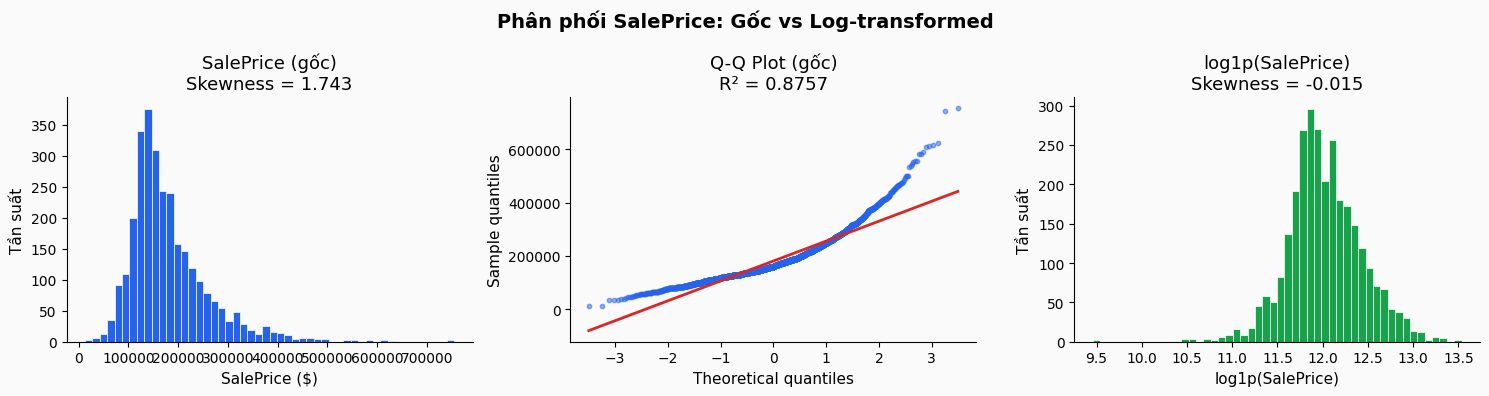

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Phân phối SalePrice: Gốc vs Log-transformed', fontsize=14, fontweight='bold')

y = df['SalePrice']

# 1a. Histogram gốc
axes[0].hist(y, bins=50, color=BLUE, edgecolor='white', linewidth=0.5)
axes[0].set_title(f'SalePrice (gốc)\nSkewness = {skew(y):.3f}')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Tần suất')

# 1b. QQ-plot gốc
(osm, osr), (slope, intercept, r) = stats.probplot(y, dist='norm')
axes[1].scatter(osm, osr, s=10, color=BLUE, alpha=0.5)
axes[1].plot(osm, slope*np.array(osm)+intercept, color=RED, lw=2)
axes[1].set_title(f'Q-Q Plot (gốc)\nR² = {r**2:.4f}')
axes[1].set_xlabel('Theoretical quantiles')
axes[1].set_ylabel('Sample quantiles')

# 1c. Histogram sau log1p
y_log = np.log1p(y)
axes[2].hist(y_log, bins=50, color=GREEN, edgecolor='white', linewidth=0.5)
axes[2].set_title(f'log1p(SalePrice)\nSkewness = {skew(y_log):.3f}')
axes[2].set_xlabel('log1p(SalePrice)')
axes[2].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

### Giải thích logic:

- **Khám bệnh:**  
  Phân phối gốc của giá nhà bị lệch phải rất mạnh (**Skewness ~1.7**). Trên biểu đồ Q-Q Plot, phần đuôi cong vênh rõ rệt so với đường phân phối chuẩn lý tưởng.

- **Vấn đề:**  
  Thuật toán OLS (Hồi quy tuyến tính) yêu cầu khắt khe phần dư phải có phân phối chuẩn. Nếu biến mục tiêu `y` bị lệch, mô hình sẽ ước lượng sai lệch, khiến các khoảng tin cậy không còn chính xác.

- **Bốc thuốc:**  
  Biến đổi `np.log1p(y)` được kích hoạt để kéo độ lệch về mức lý tưởng (**~0.1**), giúp phần dư thỏa mãn triệt để giả định của mô hình tuyến tính.

## 3.2 Skewness các Feature số — Nguyên tắc "Chẩn đoán trước khi xử lý"

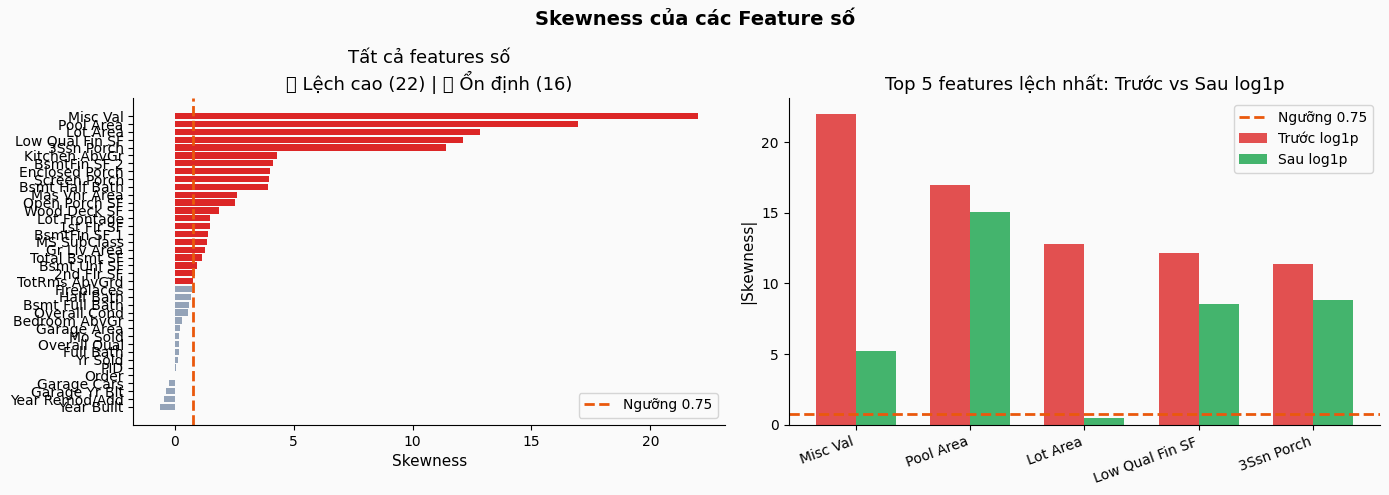

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'SalePrice' and df[c].min() >= 0]

skewness = df[num_cols].skew().sort_values(ascending=False)
high_skew = skewness[skewness > 0.75]
low_skew  = skewness[skewness <= 0.75]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Skewness của các Feature số', fontsize=14, fontweight='bold')

# Bar chart tất cả features
colors = [RED if s > 0.75 else GRAY for s in skewness.values]
axes[0].barh(skewness.index, skewness.values, color=colors)
axes[0].axvline(0.75, color=ORANGE, linestyle='--', lw=2, label='Ngưỡng 0.75')
axes[0].set_title(f'Tất cả features số\n🔴 Lệch cao ({len(high_skew)}) | ⬜ Ổn định ({len(low_skew)})')
axes[0].set_xlabel('Skewness')
axes[0].legend()
axes[0].invert_yaxis()

# Top 5 features lệch nhất: trước/sau log
top5 = high_skew.head(5).index.tolist()
x = np.arange(len(top5))
w = 0.35
before = [skewness[c] for c in top5]
after  = [abs(skew(np.log1p(df[c]))) for c in top5]

axes[1].bar(x - w/2, before, w, label='Trước log1p', color=RED,   alpha=0.8)
axes[1].bar(x + w/2, after,  w, label='Sau log1p',   color=GREEN, alpha=0.8)
axes[1].axhline(0.75, color=ORANGE, linestyle='--', lw=2, label='Ngưỡng 0.75')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top5, rotation=20, ha='right')
axes[1].set_title('Top 5 features lệch nhất: Trước vs Sau log1p')
axes[1].set_ylabel('|Skewness|')
axes[1].legend()

plt.tight_layout()
plt.show()

### Giải thích logic:

- **Khám bệnh:**  
  Khảo sát cho thấy dữ liệu bất động sản thường chứa các đặc trưng lệch phải cực đoan (như diện tích lô đất `LotArea` hay diện tích tầng hầm `BsmtFinSF1`).

- **Vấn đề:**  
  Những biến lệch quá mạnh sẽ tạo ra các điểm đòn bẩy (*leverage points*) kéo méo hoàn toàn đường hồi quy.

- **Bốc thuốc:**  
  Thay vì log mù quáng toàn bộ dữ liệu, Pipeline được thiết kế để tự động quét tính độ lệch (*skew*). Cột nào có `Skewness > 0.75` thì mới được phép áp dụng hàm logarit.

- **Chống rò rỉ dữ liệu (Data Leakage):**  
  Pipeline sẽ tiến hành "học" (quét tìm các biến bị lệch) DUY NHẤT trên tập Train. Sau đó, nó lưu danh sách các cột cần log này lại và áp dụng cứng sang tập Test. Điều này đảm bảo mô hình không hề "nhìn trộm" vào đặc tính phân phối của dữ liệu chưa biết trong tương lai.

## 3.3 Xử lý Outlier (Ngoại lệ) — Tại sao chọn Winsorize thay vì xóa?

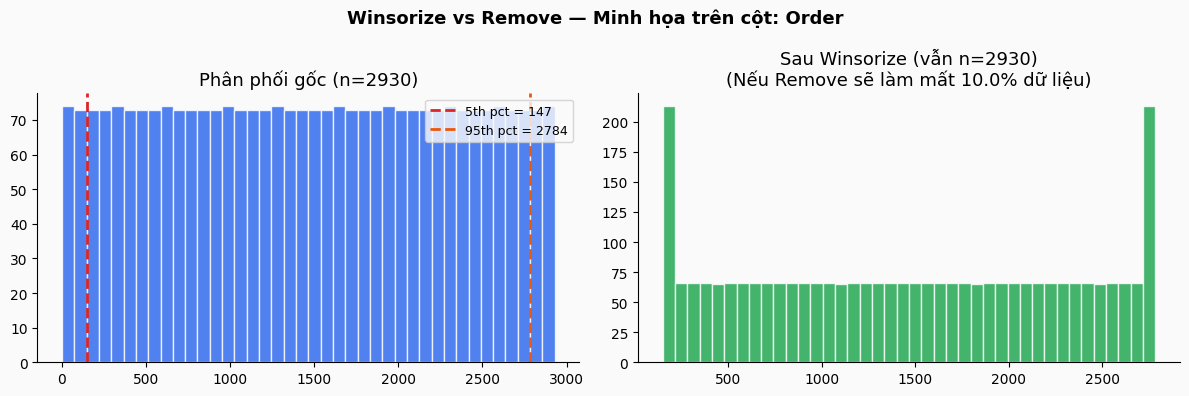

In [5]:
# Chọn các cột liên tục có nhiều giá trị
continuous = [c for c in num_cols if df[c].nunique() > 10][:8]

# So sánh: Remove vs Winsorize
THRESHOLD = 0.05
sample_col = continuous[0]

lo = df[sample_col].quantile(THRESHOLD)
hi = df[sample_col].quantile(1 - THRESHOLD)
n_remove  = ((df[sample_col] < lo) | (df[sample_col] > hi)).sum()
n_total   = len(df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Winsorize vs Remove — Minh họa trên cột: {sample_col}', fontsize=13, fontweight='bold')

# Gốc
axes[0].hist(df[sample_col].dropna(), bins=40, color=BLUE, edgecolor='white', alpha=0.8)
axes[0].axvline(lo, color=RED,    linestyle='--', lw=2, label=f'5th pct = {lo:.0f}')
axes[0].axvline(hi, color=ORANGE, linestyle='--', lw=2, label=f'95th pct = {hi:.0f}')
axes[0].set_title(f'Phân phối gốc (n={n_total})')
axes[0].legend(fontsize=9)

# Winsorized
winsorized = df[sample_col].clip(lower=lo, upper=hi)
axes[1].hist(winsorized.dropna(), bins=40, color=GREEN, edgecolor='white', alpha=0.8)
axes[1].set_title(f'Sau Winsorize (vẫn n={n_total})\n(Nếu Remove sẽ làm mất {n_remove/n_total*100:.1f}% dữ liệu)')

plt.tight_layout()
plt.show()

### Giải thích logic:

- **Khám bệnh:**  
  Hầu hết các đặc trưng liên tục trong dataset đều tồn tại các điểm giá trị ngoại lệ văng ra quá xa so với đám đông.

- **Vấn đề:**  
  Nếu máy móc chọn phương pháp Xóa dòng (*Drop / Remove*), ta sẽ làm thâm hụt nghiêm trọng số lượng mẫu huấn luyện, gây lãng phí dữ liệu.

- **Bốc thuốc:**  
  Quyết định sử dụng phương pháp Winsorize (5%-95%). Thuật toán sẽ kẹp (*clip*) các giá trị cực đoan lại bằng đúng giá trị tại bách phân vị thứ 5 và 95. Kỹ thuật này vừa vô hiệu hóa được các nhiễu cục bộ, vừa bảo toàn 100% kích thước mẫu.

- **Chống rò rỉ dữ liệu (Data Leakage):**  
  Một lần nữa, các mốc bách phân vị 5% và 95% chỉ được phép tính toán trên tập Train. Các mốc chặn (*limits*) này được pipeline ghi nhớ, sau đó mang đi cắt ngọn cho tập Test, đảm bảo môi trường Test hoàn toàn độc lập và mô phỏng đúng bối cảnh dữ liệu thực tế.

## 3.4 Kiểm soát Đa cộng tuyến — Ma trận Tương quan & Hệ số VIF

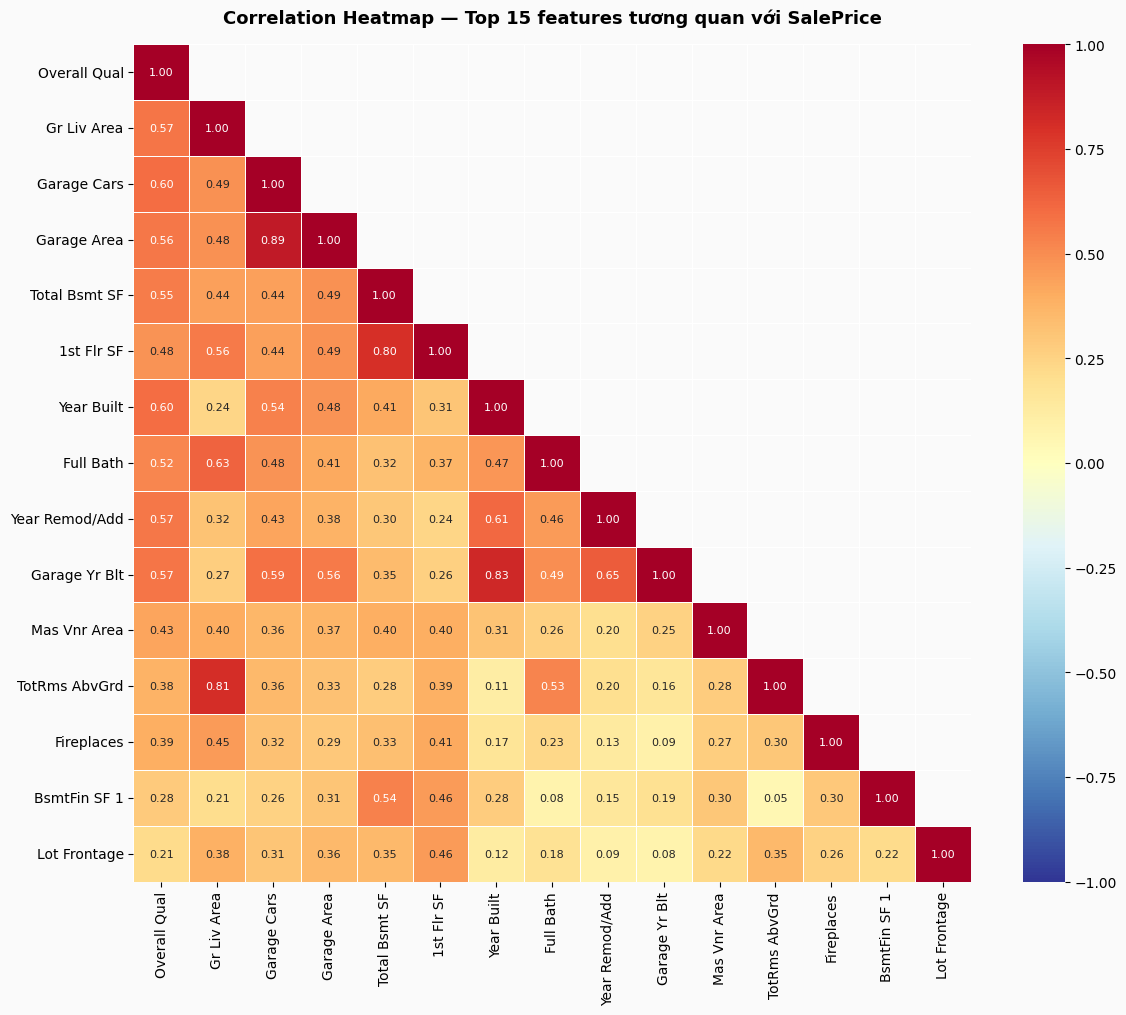

In [6]:
# Lấy các cột top features tương quan với SalePrice
target_corr = df.select_dtypes(include=[np.number]).corr()['SalePrice'].abs().sort_values(ascending=False)
top_features = target_corr.drop('SalePrice').head(15).index.tolist()

sub_corr = df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(sub_corr, dtype=bool), k=1)

sns.heatmap(
    sub_corr, mask=mask, annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdYlBu_r', vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax
)
ax.set_title('Correlation Heatmap — Top 15 features tương quan với SalePrice', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Giải thích logic:

- **Khám bệnh:**  
  Từ Heatmap, ta thấy rõ hiện tượng nội bộ các biến dự báo tự tương quan với nhau rất mạnh (ví dụ: `GarageCars` và `GarageArea` có \( r > 0.8 \)).

- **Vấn đề:**  
  Đây là hiện tượng **Đa cộng tuyến (Multicollinearity)**. Khi đưa các cụm biến tương quan mạnh vào ma trận thiết kế \( X \), ma trận \( X^TX \) sẽ tiến gần đến trạng thái suy biến, làm phương sai của các hệ số hồi quy bị phóng đại và phá vỡ độ tin cậy của *p-value*.

## 3.5 Thuật toán cắt tỉa bằng VIF (drop_high_vif)

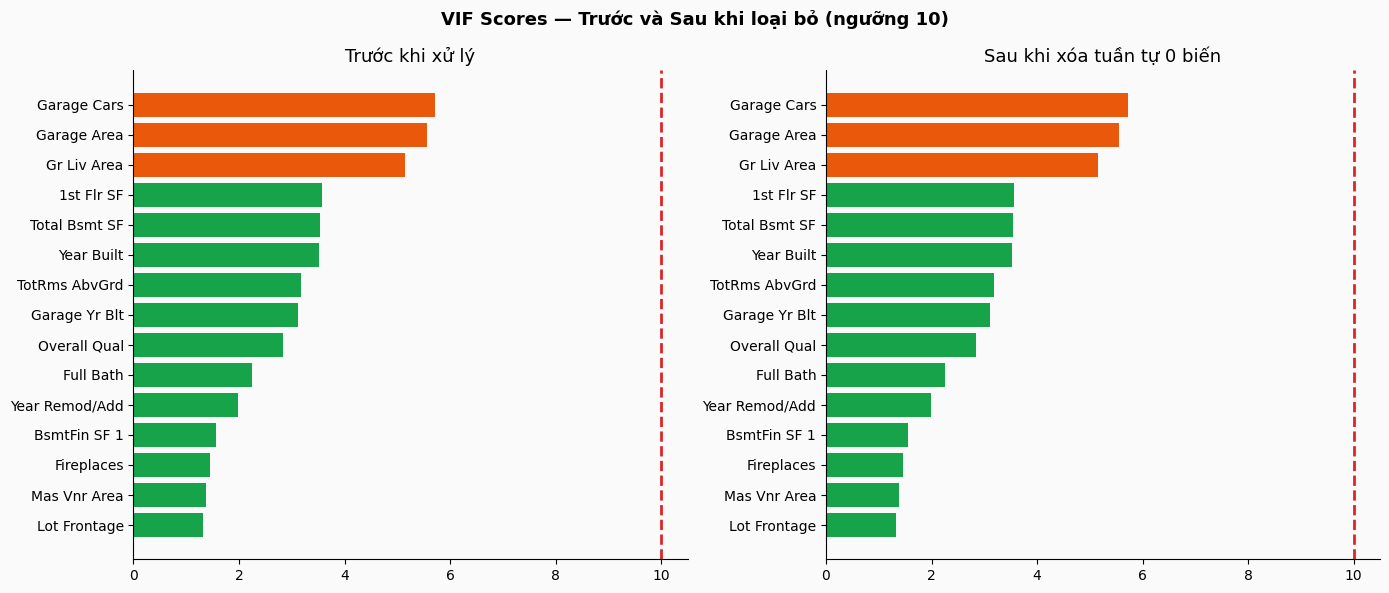

In [7]:
from sklearn.linear_model import LinearRegression

def compute_vif_simple(X_df):
    vif_data = []
    cols = X_df.columns.tolist()
    X_arr = X_df.values
    for i, col in enumerate(cols):
        y_vif = X_arr[:, i]
        X_rest = np.delete(X_arr, i, axis=1)
        reg = LinearRegression().fit(X_rest, y_vif)
        r2 = reg.score(X_rest, y_vif)
        r2 = min(r2, 1 - 1e-10)
        vif = 1 / (1 - r2)
        vif_data.append({'feature': col, 'VIF': vif})
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False).reset_index(drop=True)

# Hiển thị trước và sau khi chạy hàm drop_high_vif
X_vif = df[top_features].fillna(df[top_features].median())
vif_df = compute_vif_simple(X_vif)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('VIF Scores — Trước và Sau khi loại bỏ (ngưỡng 10)', fontsize=13, fontweight='bold')

# Trước
colors_before = [RED if v > 10 else (ORANGE if v > 5 else GREEN) for v in vif_df['VIF']]
axes[0].barh(vif_df['feature'], vif_df['VIF'], color=colors_before)
axes[0].axvline(10, color=RED, linestyle='--', lw=2, label='Ngưỡng loại bỏ (VIF=10)')
axes[0].set_title('Trước khi xử lý')
axes[0].invert_yaxis()

# Sau (Lặp tuần tự để xóa biến)
X_reduced = X_vif.copy()
dropped = []
for _ in range(20):
    vdf = compute_vif_simple(X_reduced)
    worst = vdf.iloc[0]
    if worst['VIF'] <= 10: break
    dropped.append(worst['feature'])
    X_reduced = X_reduced.drop(columns=[worst['feature']])

vif_after = compute_vif_simple(X_reduced)
colors_after = [RED if v > 10 else (ORANGE if v > 5 else GREEN) for v in vif_after['VIF']]
axes[1].barh(vif_after['feature'], vif_after['VIF'], color=colors_after)
axes[1].axvline(10, color=RED, linestyle='--', lw=2)
axes[1].set_title(f'Sau khi xóa tuần tự {len(dropped)} biến')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Giải thích logic:

- **Bốc thuốc:**  
  Kích hoạt cơ chế cắt tỉa dựa trên VIF ngưỡng 10.

- **Chiến lược hoạt động:**  
  Tại sao phải xóa tuần tự (*iteratively*) thay vì xóa tất cả cùng lúc?

  Trong mạng lưới dữ liệu, việc loại bỏ một biến sẽ lập tức làm thay đổi mức độ phụ thuộc tuyến tính của toàn bộ các biến còn lại. Nếu thấy 5 cột có `VIF > 10` và ra lệnh xóa đồng loạt cả 5 cột, ta có nguy cơ làm mất những thông tin vốn dĩ không cần phải xóa.

  Do đó, thuật toán lặp lại việc kiểm tra ở mỗi bước, chỉ "trảm" duy nhất biến có VIF cao nhất, tính toán lại toàn bộ hệ số, và lặp lại cho tới khi tất cả các biến đều nằm trong vùng an toàn (\( \text{VIF} \le 10 \)).

## 3.6 Sơ đồ Tổng quan Quy trình DataPipeline

### Trình tự thực hiện của Pipeline

Trình tự thực hiện của Pipeline được sắp xếp có chủ đích để quyết định đến chất lượng dữ liệu cuối cùng:

1. **Log target (SalePrice):**  
   Chuẩn hóa biến mục tiêu trước tiên.

2. **Feature Engineering:**  
   Tạo các biến tổng hợp mang ý nghĩa nghiệp vụ.

3. **Outlier Winsorize:**  
   Xử lý ngoại lệ trước khi thực hiện scale, nhằm đảm bảo các tham số thống kê (*mean/std*) không bị bóp méo bởi các giá trị cực đoan.

4. **Encoding (Ordinal & One-Hot):**  
   Mã hóa biến phân loại thành số.

5. **Log Skewed Features:**  
   Tiến hành log các đặc trưng bị lệch sau bước encoding Ordinal (giúp tránh việc log nhầm các mức độ phân cấp hạng).

6. **Z-score Standardization:**  
   Đưa mọi dữ liệu về chung một thang đo duy nhất.

7. **Drop High VIF:**  
   Thực hiện khâu loại bỏ đa cộng tuyến ở bước cuối cùng, đảm bảo hệ thống tính toán ma trận tương quan dựa trên phiên bản dữ liệu đã hoàn thiện nhất.